<a name="top" id="top"></a>

<div align="center">
    <h1>Quantum Annealing via D-Wave</h1>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/pedromxavier">Pedro Maciel Xavier</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>  
    <br>  
    <a href="https://github.com/AzAINN">Azain Khalid</a>
    <br>
    <i>Department of Computer Science, Purdue University</i>
    <br>
    <i> Undergraduate Researcher</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/JuliaQUBO/QUBONotebooks/blob/main/notebooks_jl/4-DWave.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

### Activate Environment

In [50]:
import Pkg; Pkg.activate(@__DIR__) # Here we go!

  Activating project at `c:\Users\azain\QUBONotebooks\QUBONotebooks\notebooks_jl`


## About this Notebook

This notebook will give the first interaction with D-Wave's Quantum Annealer.
It will use the QUBO modeling problem introduced earlier and will define it using **[JuMP](https://jump.dev)**, and then solve them using neal's implementation of simulated annealing classicaly and D-Wave system package to use Quantum Annealing.
We will also leverage the use of **[Graphs.jl](https://github.com/JuliaGraphs/Graphs.jl)** for network models/graphs.

## Problem statement

We define a QUBO as the following optimization problem:

$$
\min_{x \in \{0,1 \}^n} \sum_{(ij) \in E(G)} Q_{ij}x_i x_j + \sum_{i \in V(G)}Q_{ii}x_i + \beta = \min_{x \in \{0,1 \}^n}  \mathbf{x}' \mathbf{Q} \mathbf{x} + \beta
$$

where we optimize over binary variables $x \in \{ 0,1 \}^n$, on a constrained graph $G(V,E)$ defined by a weighted adjacency matrix $\mathbf{Q}$.
We also include an arbitrary offset  $\beta$.

### Example

Suppose we want to solve the following problem via QUBO

$$
\begin{array}{rl}
\displaystyle%
\min_{\mathbf{x}} & 2x_0+4x_1+4x_2+4x_3+4x_4+4x_5+5x_6+4x_7+5x_8+6x_9+5x_{10} \\
\textrm{s.t.}     & \begin{bmatrix}
1 & 0 & 0 & 1 & 1 & 1 & 0 & 1 & 1 & 1 & 1\\
0 & 1 & 0 & 1 & 0 & 1 & 1 & 0 & 1 & 1 & 1\\
0 & 0 & 1 & 0 & 1 & 0 & 1 & 1 & 1 & 1 & 1
\end{bmatrix}\mathbf{x}=
\begin{bmatrix}
1\\
1\\
1
\end{bmatrix} \\
~ & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

First we would write this problem as a an unconstrained one by penalizing the linear constraints as quadratics in the objective.
Let's first define the problem parameters.

In [2]:
A = [
    1 0 0 1 1 1 0 1 1 1 1
    0 1 0 1 0 1 1 0 1 1 1
    0 0 1 0 1 0 1 1 1 1 1
]
b = [1, 1, 1]
c = [2, 4, 4, 4, 4, 4, 5, 4, 5, 6, 5];

In order to define the $\mathbf{Q}$ matrix, we first write the problem

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} &\mathbf{c}' \mathbf{x} \\
    \textrm{s.t.}     & \mathbf{A}\mathbf{x} = \mathbf{b} \\
    ~                 & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

as follows:

$$
\begin{array}{rl}
    \displaystyle%
    \min_{\mathbf{x}} & \mathbf{c}' \mathbf{x} + \rho (\mathbf{A}\mathbf{x}-\mathbf{b})' (\mathbf{A}\mathbf{x}-\mathbf{b}) \\
    \textrm{s.t.}     & \mathbf{x} \in \{0,1 \}^{11}
\end{array}
$$

Exploiting the fact that $x^2=x$ for $x \in \{0,1\}$, we can make the linear terms appear in the diagonal of the $\mathbf{Q}$ matrix.

$$
\rho(\mathbf{A}\mathbf{x}-\mathbf{b})'(\mathbf{A}\mathbf{x}-\mathbf{b}) = \rho( \mathbf{x}'(\mathbf{A}'\mathbf{A}) \mathbf{x} - 2(\mathbf{A}'\mathbf{b}) \mathbf{x} + \mathbf{b}'\mathbf{b} )
$$

For this problem in particular, one can prove that a reasonable penalization factor is given by $\rho = \sum_{i=1}^n |c_i| + \epsilon$ with $\epsilon > 0$.

In [3]:
using LinearAlgebra

In [4]:
ϵ = 1
ρ = sum(abs, c) + ϵ
Q = diagm(c) + ρ * (A'A - 2 * diagm(A'b))
β = ρ * b'b

display(Q)
println(β)

11×11 Matrix{Int64}:
 -46    0    0   48   48   48    0   48    48    48    48
   0  -44    0   48    0   48   48    0    48    48    48
   0    0  -44    0   48    0   48   48    48    48    48
  48   48    0  -92   48   96   48   48    96    96    96
  48    0   48   48  -92   48   48   96    96    96    96
  48   48    0   96   48  -92   48   48    96    96    96
   0   48   48   48   48   48  -91   48    96    96    96
  48    0   48   48   96   48   48  -92    96    96    96
  48   48   48   96   96   96   96   96  -139   144   144
  48   48   48   96   96   96   96   96   144  -138   144
  48   48   48   96   96   96   96   96   144   144  -139

144


We can visualize the graph that defines this instance using the Q matrix as the adjacency matrix of a graph.

In [ ]:
try @eval using QUBOTools catch; Pkg.add("QUBOTools"); end
try @eval using Plots catch; Pkg.add("Plots"); end

using QUBOTools
using Plots

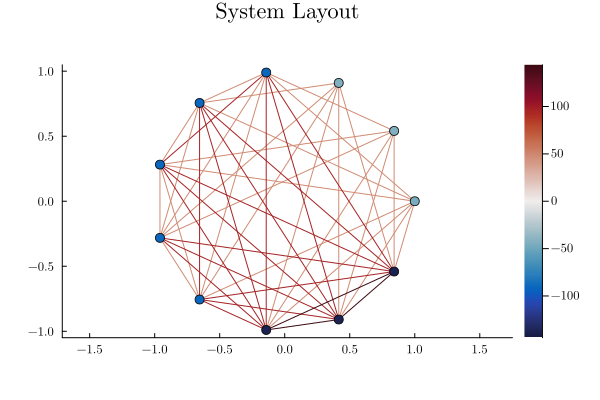

In [6]:
plot(QUBOTools.SystemLayoutPlot(Q)) 

Let's define a QUBO model and then solve it via simulated annealing.

In [ ]:
try @eval using JuMP catch; Pkg.add("JuMP"); end
try @eval using QUBO catch; Pkg.add("QUBO"); end
try @eval using DWave catch; Pkg.add("DWave"); end

using JuMP
using QUBO
using DWave

# The 'DWAVE_API_TOKEN' variable not defined warning is for accessing quantum hardware, for our
# simulated anneal run we don't need to define it yet

In [8]:
# Define empty model
qubo_model = Model()

# Define the variables
@variable(qubo_model, x[1:11], Bin)

# Define the objective function
@objective(qubo_model, Min, x' * Q * x + β)

# Print the model
print(qubo_model)

In [9]:
# Use D-Wave's simulated annealer 'Neal'
set_optimizer(qubo_model, DWave.Neal.Optimizer)  

set_optimizer_attribute(qubo_model, "num_reads", 1_000)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


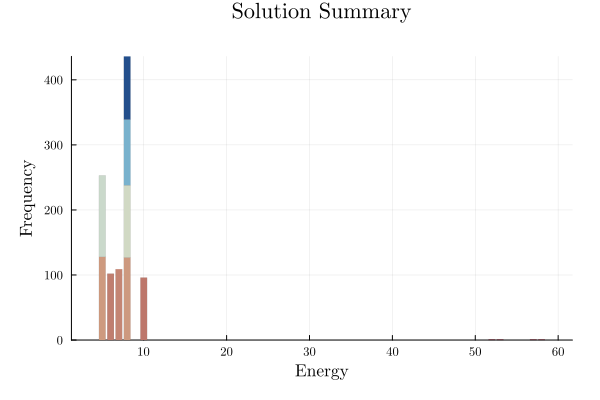

In [10]:
q_model = unsafe_backend(qubo_model).model  
# We require QUBOTools.AbstractModel from JuMP model to efficiently use the visualization methods
plot(QUBOTools.EnergyFrequencyPlot(q_model)) 

Notice that this is the same example we have been solving earlier (via Integer Programming in the Quiz 2, via Ising model and QUBO in Notebook 2).

## Now let's solve this using Quantum Annealing!

First, we start by defining the `DWAVE_API_TOKEN` environment variable.

In [ ]:
ENV["DWAVE_API_TOKEN"] = "<YOUR_KEY_HERE>";

In [12]:
# Use D-Wave's quantum annealer
set_optimizer(qubo_model, DWave.Optimizer)

set_optimizer_attribute(qubo_model, "num_reads", 1024)

optimize!(qubo_model)

println("Minimum energy: $(objective_value(qubo_model))")

Minimum energy: 5.0


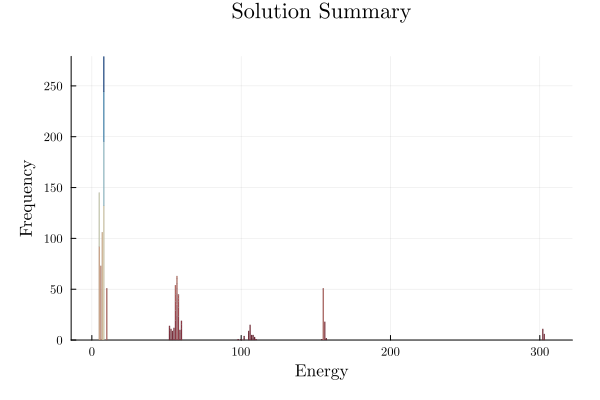

In [13]:
qubo_model = unsafe_backend(qubo_model).model 
plot(QUBOTools.EnergyFrequencyPlot(qubo_model))

In [31]:
# Build a QPU sampler (let Leap pick something available)
sampler = DWave.dwave_system.DWaveSampler(token = ENV["DWAVE_API_TOKEN"], solver=Dict("qpu" => true))

Python: <dwave.system.samplers.dwave_sampler.DWaveSampler object at 0x0000022B0F4907D0>

In [44]:
try @eval import PythonCall catch; Pkg.add("PythonCall"); end
try @eval using Graphs catch; Pkg.add("Graphs"); end
try @eval using GraphPlot catch; Pkg.add("GraphPlot"); end

import PythonCall: pyimport, pyconvert, pystr, Py # To convert the Python NetworkX graph to Julia Graphs.jl
using Graphs
using GraphPlot


Solver id:     Advantage_system6.4
Topology:      pegasus  shape=[16]
Working graph: 5612 qubits, 40088 couplers
Plotting induced subgraph on first 1500 nodes: 9965 couplers


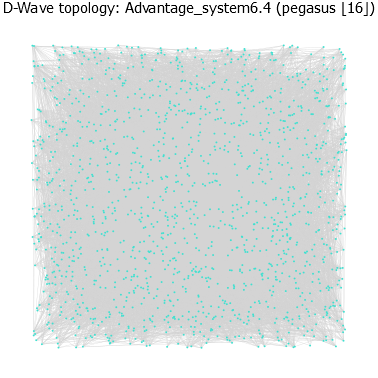

In [ ]:

function draw_topology(sampler::Py; max_nodes::Int=1500, layout=random_layout)

    sid  = pystr(String, sampler.solver.id)

    topo = sampler.properties["topology"]
    ttype = pystr(String, topo["type"])
    shape = pyconvert(Vector{Int}, topo["shape"])

    # Working hardware graph as a NetworkX graph
    Gpy = sampler.to_networkx_graph()

    builtins = pyimport("builtins")
    nodes = pyconvert(Vector{Int}, builtins.list(Gpy.nodes()))
    edges = pyconvert(Vector{Tuple{Int,Int}}, builtins.list(Gpy.edges()))

    println("Solver id:     $sid")
    println("Topology:      $ttype  shape=$(shape)")
    println("Working graph: $(length(nodes)) qubits, $(length(edges)) couplers")

    # Full QPU graphs are huge; plotting them can be slow/unreadable.
    # So we print full counts, and plot an induced subgraph.
    if length(nodes) > max_nodes
        keep = nodes[1:max_nodes]
        keep_set = Set(keep)
        edges = [(u,v) for (u,v) in edges if (u in keep_set && v in keep_set)]
        nodes = keep
        println("Plotting induced subgraph on first $max_nodes nodes: $(length(edges)) couplers")
    end

    idx = Dict{Int,Int}(n => i for (i,n) in enumerate(nodes))
    g = SimpleGraph(length(nodes))
    for (u,v) in edges
        add_edge!(g, idx[u], idx[v])
    end

    return gplot(
        g;
        layout=layout,
        title="D-Wave topology: $sid ($ttype $(shape))",
        nodelabel=nothing,
        nodesize=10,
        edgelinewidth=0.1,
    )
end

display(draw_topology(sampler))


# References

- [Julia Colab Notebook Template](https://colab.research.google.com/github/ageron/julia_notebooks/blob/master/Julia_Colab_Notebook_Template.ipynb)
- [QuIPML22](https://github.com/bernalde/QuIPML22/)

<div align="center">
    <a href="#top">🔝 Go back to the top 🔝</a>
</div>